# Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    import wandb
except ImportError:
    wandb = None
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import print_mol_types
from src.data.graph_building import build_graph_features
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import mask_data, preprocess
from src.data.cleaning import fragment_count, is_salt, has_metal, is_single_node
from src.data.splitting import butina_split, show_split_info
from src.data.sampling import LoadData, show_loader_info
from src.training.loops import train
from src.visualization.training_plots import  plot_training, plot_training_metrics, plot_group_training


pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

print("Setup complete")
print(f"Data file: {DATA_PATH}")


/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete
Data file: /home/vollmers/gnn-thesis/Data/toxicity_all.csv


# Load And Filter Data


In [2]:
selected_columns = [
    'SK_unique_id',
    'species_common_name',
    'species_latin_name',
    'CAS',
    'chemical_name',
    'conc_unit',
    'conc',
    'duration',
    'duration_unit',
    'effect',
    'endpoint',
    'SMILES',
    'organism_lifestage_categorized',
    'administration_route_categorized',
    'NCBI_sci_name',
    'NCBI_last_known_rank',
    'NCBI_rank_superkingdom',
    'NCBI_rank_kingdom',
    'NCBI_rank_phylum',
    'NCBI_rank_subphylum',
    'NCBI_rank_class',
    'NCBI_rank_order',
    'NCBI_rank_family',
    'NCBI_rank_genus',
    'NCBI_rank_species',
    'species_group_corrected'
]

df_all = load_data(DATA_PATH, selected_columns)

df_all = df_all.rename(columns={
    'species_group_corrected': 'species_group',
    'organism_lifestage_categorized': 'organism_lifestage',
    'administration_route_categorized': 'administration_route'
})

# Rename columns starting with NCBI_ to be more concise
df_all = df_all.rename(columns={
    'NCBI_rank_superkingdom': 'superkingdom',
    'NCBI_rank_kingdom': 'kingdom',
    'NCBI_rank_phylum': 'phylum',
    'NCBI_rank_subphylum': 'subphylum',
    'NCBI_rank_class': 'class',
    'NCBI_rank_order': 'order',
    'NCBI_rank_family': 'family',
    'NCBI_rank_genus': 'genus',
    'NCBI_rank_species': 'species',
    'NCBI_sci_name': 'species_sci_name',
    'NCBI_last_known_rank': 'taxid'
})

# Fill missing organimsm_lifestage -> adult, administration_route -> fill, duration_unit -> h
df_all['organism_lifestage'] = df_all['organism_lifestage'].fillna('adult')
df_all['administration_route'] = df_all['administration_route'].fillna('fill')
df_all['duration_unit'] = df_all['duration_unit'].fillna('h')

# Filters
filters = {
    # "conc_unit": ["mg/L"],
    "duration_unit": ["h"],
    # "endpoint": ["EC50"],
    "effect": ["MOR", "POP", "GRO", "BEH", "REP", "ITX", "PHY", "DVP", "MPH"],
}
require_duration = False
require_taxonomy = True

taxonomy_cols = (
    "class",
    "family",
    "genus",
    "species",
)

# Create mask
mask = mask_data(
    df_all,
    filters=filters,
    require_duration=require_duration,
    require_taxonomy=require_taxonomy,
    taxonomy_columns=taxonomy_cols,
)

# Apply mask and filter
df_filtered = df_all.loc[mask].copy()

# Convert taxonomy columns to numeric, coercing errors to NaN and then to nullable Int64
for col in taxonomy_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors="coerce").astype("Int64")

print()
print("Loaded and filtered training data")
print(f"Rows in full data: {len(df_all):,}")
print(f"Rows after filter: {len(df_filtered):,}")
print()
print("Filtered preview")
print(df_filtered.head())


Filters
duration_unit: ['h']
True: 0.980
effect: ['MOR', 'POP', 'GRO', 'BEH', 'REP', 'ITX', 'PHY', 'DVP', 'MPH']
True: 0.981
require_taxonomy: True
True: 0.916

Loaded and filtered training data
Rows in full data: 561,100
Rows after filter: 495,422

Filtered preview
  SK_unique_id species_common_name species_latin_name          CAS  \
0       RTECS7               mouse       Mus musculus  108073-64-9   
1      RTECS41               mouse       Mus musculus   78111-17-8   
2     RTECS137               mouse       Mus musculus    4657-93-6   
3     RTECS140               mouse       Mus musculus  102585-20-6   
4     RTECS141                 rat  Rattus norvegicus      83-32-9   

                                                                     chemical_name  \
0  5H-Pyrrolo(2,1-c)(1,4)benzodiazepin-5-one, 1,2,3,10,11,11a-hexahydro-2-hydro...   
1                                   Acanthifolicin, 9,10-deepithio-9,10-didehydro-   
2                                                     

# Preprocess Molecules And Targets


In [3]:
# Cut dataset for faster experiments
MAX_ROWS = 80000  # set to an integer like 15000 for faster experiments
# MAX_ROWS = None
random_state = 11

# Optionally limit the number of rows for faster experiments
if MAX_ROWS is not None and len(df_filtered) > MAX_ROWS:
    df_filtered = df_filtered.sample(n=MAX_ROWS, random_state=random_state).reset_index(drop=True)
else:
    df_filtered = df_filtered.reset_index(drop=True)


# Preprocess data
SPLIT_SALTS = False
REMOVE_LONE = False
REMOVE_METALS = False

MAX_CONC_VALUE = 10000
DURATION_FILL_VALUE = 1e-6
MAX_DURATION_HOURS = 9000.0
LOG_TRANSFORM_DURATION = True

df_processed = preprocess(
    df_filtered.copy(),
    split_salts=False,
    remove_lone=False,
    remove_metals=False,
    max_conc_value=MAX_CONC_VALUE,
    duration_fill_value=DURATION_FILL_VALUE,
    max_duration_hours=MAX_DURATION_HOURS,
    log_transform_duration=True,
    keep_duration_raw=True,
)

print(f"Rows before preprocessing: {len(df_filtered):,}")
print(f"Rows after preprocessing:  {len(df_processed):,}")
print(f"Rows removed: {len(df_filtered) - len(df_processed):,}")
print()
print("Preprocessed preview")
print(df_processed[["SMILES", "duration_raw", "duration", "conc", "log10c", "species_group"]].head())
print()
print_mol_types(df_processed)


Rows before preprocessing: 80,000
Rows after preprocessing:  78,507
Rows removed: 1,493

Preprocessed preview
                                   SMILES  duration_raw  duration        conc  \
0                              [F-].[Na+]          96.0  1.982271  272.000000   
1     COc1cc(OC)nc(Sc2cccc(Cl)c2C(=O)O)n1         504.0  2.702431    0.000007   
2                                       S          96.0  1.982271    0.063000   
3  O=[N+]([O-])c1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl          96.0  1.982271    1.500000   
4                       CCCN(CCC)C(=O)SCC         672.0  2.827369    0.000100   

     log10c species_group  
0  2.434569         algae  
1 -5.148742        plants  
2 -1.200659   crustaceans  
3  0.176091          fish  
4 -4.001062        plants  

Total molecules: 78507
Unique molecules: 21099
Disconnected species: 19688, 25.08%
Single-node species: 1438, 1.83%
Metals: 14818, 18.87%


# Encoding Data

## Featiruze molecules

In [4]:
from src.data.featurization import simple_featurizer

# df_processed["features"] = df_processed["SMILES"].apply(from_smiles)

# atom_features = ["atomic_num", "mass"]
# bond_features = ["bond_order"]
df_processed["features"] = df_processed["SMILES"].apply(simple_featurizer)

sample_id = min(16, len(df_processed) - 1)

print()
print(f"{len(df_processed):,} rows with graph features created")


78,507 rows with graph features created


## Taxonomy Encoding

In [5]:
USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = "../Data/moredata/pretrained_tax_emb.pkl.zip"

tax_embedding = {
    "taxid": 16,
    # "species_group": 16,
    # "genus": 8,
    # "family": 8,
    # "class": 4,
}

# Remove taxid from embedding if using pretrained taxid embeddings
model_tax_embedding = (
    {key: value for key, value in tax_embedding.items() if key != "taxid"}
    if USE_PRETRAINED_TAXID
    else tax_embedding
)

df_tax = df_processed[list(tax_embedding.keys())].copy()
df_tax, tax_encoders = sequential_encoder(df_tax, tax_embedding.keys())
# df_tax now contains only the sequential data for selected columns

config_tax = build_config(df_tax, model_tax_embedding)
taxid_decoder = {encoded: original for original, encoded in tax_encoders["taxid"].items()}

# species_decoder = {encoded: original for original, encoded in tax_encoders["species_group"].items()}

if not USE_PRETRAINED_TAXID:
    print("Don't use pretrained taxid embeddings")
    print("Taxonomy embedding config")
    print(config_tax)


if USE_PRETRAINED_TAXID:
    print(f"Use pretrained taxid embeddings")
    print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

Use pretrained taxid embeddings
Pretrained taxid path: ../Data/moredata/pretrained_tax_emb.pkl.zip


## Categorical and Numerical Encoding

In [6]:
# Add some more metadata cols
df_processed["fragment_count"] = df_processed["SMILES"].apply(fragment_count).astype(float)
df_processed["is_salt"] = df_processed["SMILES"].apply(is_salt).astype(float)
df_processed["has_metal"] = df_processed["SMILES"].apply(has_metal).astype(float)
df_processed["is_single_node"] = df_processed["SMILES"].apply(is_single_node).astype(float)

# Categorical encoding
categorical_cols = [
    "species_group",
    "conc_unit",
    "endpoint", 
    "effect", 
    "is_salt",
    "has_metal",
    "is_single_node",
    ]

df_categorical = df_processed[categorical_cols].copy()
df_categorical, categorical_encoder = sequential_encoder(df_categorical, categorical_cols)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, categorical_cols)

categorical_decoder = {encoded: original for original, encoded in categorical_encoder["species_group"].items()}

print("Categorical embedding config:")
print(config_categorical)
print()

# Numerical encoding 
numerical_cols = [
    "duration",
    "fragment_count",
    # "is_salt",
    # "has_metal",
    # "is_single_node",
]

print("Numerical encoding for:")
print(numerical_cols)


Categorical embedding config:
{'species_group': 20, 'conc_unit': 14, 'endpoint': 4, 'effect': 9, 'is_salt': 2, 'has_metal': 2, 'is_single_node': 2}

Numerical encoding for:
['duration', 'fragment_count']


# Build The Final Graph Dataset


In [7]:
features = build_graph_features(
    df_processed, 
    df_tax, 
    tax_embedding, 
    df_categorical,
    categorical_cols,
    numerical_cols
    )

sample_feature = features[sample_id]

print(f"Graph objects created: {len(features):,}")
print()
print("Info for a sample:")
print(features[sample_id])


Graph objects created: 78,507

Info for a sample:
Data(x=[10, 7], edge_index=[2, 18], edge_attr=[18, 3], smiles='CSC1=NCCCCN1.I', y=1.7481880187988281, row_id=16, taxid=5, taxid_raw=10090, species_group=4, conc_unit=3, endpoint=0, effect=1, is_salt=0, has_metal=1, is_single_node=0, duration=-6.0, fragment_count=2.0)


# Prepare for training

## Split data

Using csv file for butina splitting: ../Data/moredata/original/butina_cluster_lookup.csv
Using stratified splitting with stratify_by: ['species_group', 'endpoint', 'effect', 'conc_unit']
Train size: 54,941 (70.0%)
Val size:   7,854 (10.0%)
Test size:  15,712 (20.0%)

Unique molecules in train: 20,709
Unique molecules in val:   78
Unique molecules in test:  312
Val molecules not in train:  78
Test molecules not in train: 312

Target distribution
Train mean/std: 0.6581 / 2.2679
Val mean/std:   -0.6851 / 2.2770
Test mean/std:  -0.3478 / 2.2897


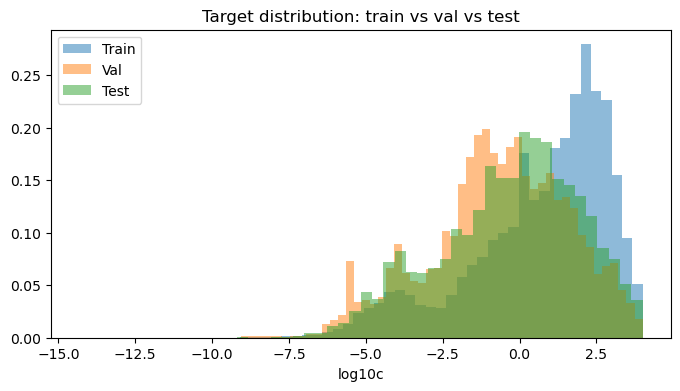

In [8]:
split_method = "butina"
cluster_col = "Cluster_at_cutoff_0.2"
stratify_by = ["species_group", "endpoint", "effect", "conc_unit"]
# stratify_by = None
frac_train = 0.7
frac_valid = 0.1
frac_test = 0.2
cluster_csv_path = "../Data/moredata/original/butina_cluster_lookup.csv"

train_dataset, val_dataset, test_dataset = butina_split(
    features,
    stratify_by=stratify_by,
    frac_train=frac_train,
    frac_test=frac_test,
    frac_valid=frac_valid,
    cluster_csv_path=cluster_csv_path,
    cluster_col=cluster_col,   
)

show_split_info(train_dataset, val_dataset, test_dataset)

## Build DataLoaders


Train: 54941 dataset samples, 54941 sampled samples, 215 batches (batch_size=256)
Val: 7854 dataset samples, 7854 sampled samples, 31 batches (batch_size=256)
Test: 15712 dataset samples, 15712 sampled samples, 62 batches (batch_size=256)


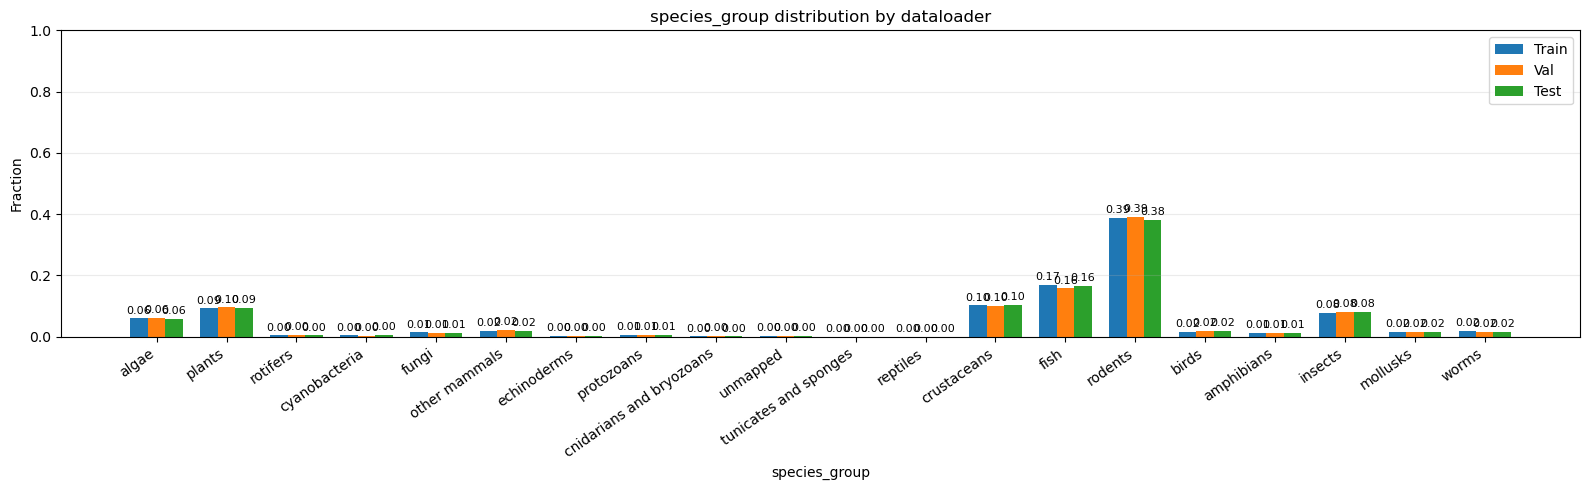

In [9]:
BATCH_SIZE = 256
attribute = "species_group"

train_loader = LoadData(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    attribute=attribute
)

val_loader = LoadData(
    dataset=val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    attribute=attribute,
    target_dataset=train_dataset
)

test_loader = LoadData(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    attribute=attribute,
    target_dataset=train_dataset
)

show_loader_info(attribute, train_loader, val_loader, test_loader, categorical_decoder)

# next(iter(train_loader))

# Model and training


## Build model

In [10]:
from src.models.attentive_fp import AttentiveFP
from src.models.afp_flex import AFPFlex
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder, TaxonomyEncoder, TaxonomyOneHot

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TAX_DIM = 16
PRETRAINED_TAX_DIM = 768 # 768 is the length of the vectors in pretrained_tax_emb.pkl.zip
PRETRAINED_TAXID_OUTPUT_DIM = 128
CATEGORICAL_DIM = 16
NUMERIC_DIM = 16
META_DROPOUT = 0.3

GNN_HIDDEN_DIM = 64
GNN_OUT_DIM = 64

NUM_LAYERS = 3
NUM_TIMESTEPS = 2
DROPOUT = 0.3

FINAL_HIDDEN_DIM = 64

ATOM_FEATURE_DIM = features[0].x.shape[1]
EDGE_FEATURE_DIM = features[0].edge_attr.shape[1]

meta_encoder = MetaEncoder(
    taxonomy_encoder_cls=TaxonomyOneHot,
    config_tax=config_tax,
    tax_output_dim=TAX_DIM,
    pretrained_taxid_path=PRETRAINED_TAXID_PATH if USE_PRETRAINED_TAXID else None,
    pretrained_tax_dim=PRETRAINED_TAX_DIM,
    pretrained_taxid_output_dim=PRETRAINED_TAXID_OUTPUT_DIM,
    config_categorical=config_categorical,
    categorical_output_dim=CATEGORICAL_DIM,
    numerical_columns=numerical_cols,
    numeric_output_dim=NUMERIC_DIM,
    dropout=META_DROPOUT
).to(device)


model_gnn = AFPFlex(
    in_channels=ATOM_FEATURE_DIM,
    edge_dim=EDGE_FEATURE_DIM,
    hidden_channels=GNN_HIDDEN_DIM,
    out_channels=GNN_OUT_DIM,
    num_layers=NUM_LAYERS,
    num_timesteps=NUM_TIMESTEPS,
    dropout=DROPOUT,
).to(device)

model = ToxicityModel(
    model_gnn,
    meta_encoder,
    hidden_dim=FINAL_HIDDEN_DIM,
).to(device)

n_params_meta = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad)
n_params_gnn = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad)
n_params_total = sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"Device: {device}")
print(f"Meta encoder trainable parameters: {n_params_meta:,}")
print(f"GNN trainable parameters: {n_params_gnn:,}")
print(f"Total trainable parameters: {n_params_total:,}")
print()
print(model)


Device: cpu
Meta encoder trainable parameters: 691,472
GNN trainable parameters: 130,112
Total trainable parameters: 836,177

ToxicityModel(
  (gnn): AFPFlex(
    (lin1): Linear(in_features=7, out_features=64, bias=True)
    (gate_conv): GATEConv()
    (gru): GRUCell(64, 64)
    (atom_convs): ModuleList(
      (0-1): 2 x GATConv(64, 64, heads=1)
    )
    (atom_grus): ModuleList(
      (0-1): 2 x GRUCell(64, 64)
    )
    (mol_conv): GATConv(64, 64, heads=1)
    (mol_gru): GRUCell(64, 64)
    (linlone): Linear(in_features=64, out_features=64, bias=True)
    (lin2): Linear(in_features=64, out_features=64, bias=True)
  )
  (meta_encoder): MetaEncoder(
    (categorical_encoder): CategoricalOneHot(
      (projection): Sequential(
        (0): Linear(in_features=53, out_features=16, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.3, inplace=False)
      )
    )
    (numeric_encoder): NumericalEncoder(
      (projection): Sequential(
        (0): Linear(in_features=2, out_features=16

## Train The Model


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/vollmers/.netrc.


wandb: Currently logged in as: elonvg (elonvg-chalmers-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training configuration
epochs = 100
learning_rate = 0.0003
weight_decay = 0.0001
loss = SmoothL1Loss
early_stopping_patience = 30


Epoch 95/100:  94%|█████████▍| 94/100 [1:19:48<05:05, 50.95s/epoch, train_loss=0.5582, val_loss=0.7753, val_rmse=1.3324, val_mae=0.9963, test_loss=0.7466, test_rmse=1.2787, test_mae=0.9664, lr=7.50e-05] 


Early stopping at epoch 95: no improvement in val_loss for 30 epochs.


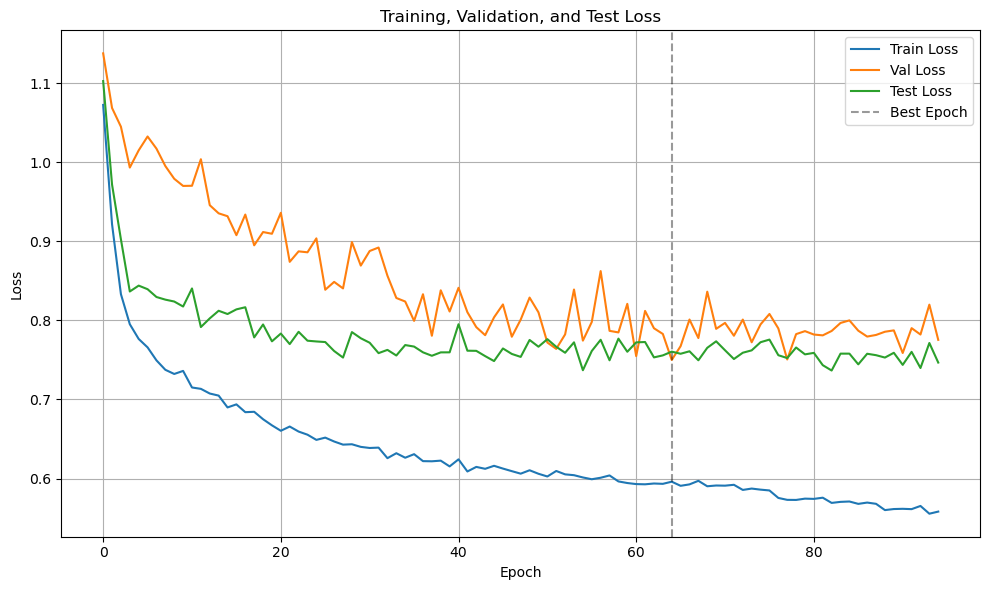

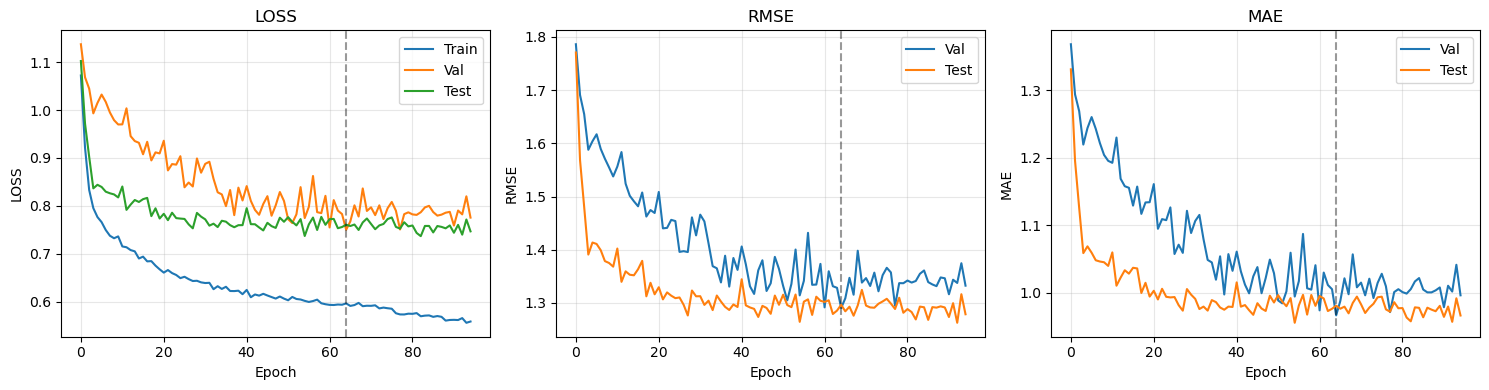

In [11]:
from src.visualization.training_plots import plot_training_metrics

epochs = 100
learning_rate = 3e-4
weight_decay = 1e-4
loss_beta = 0.5
early_stopping_patience = 30
early_stopping_min_delta = 1e-4
record_categories = ["species_group", "endpoint", "effect", "conc_unit"]

loss_fn = torch.nn.SmoothL1Loss(beta=loss_beta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
    min_lr=1e-6,
)

USE_WANDB = wandb is not None  # set to False to skip tracking
# USE_WANDB = False  # set to False to skip tracking
wandb_run = None

if USE_WANDB:
    wandb_run = wandb.init(
        project="gnn-thesis",
        entity="elonvg-chalmers-university-of-technology",
        job_type="train",
        tags=["notebook", split_method, type(model_gnn).__name__],
        config={
            "random_state": random_state,
            "n_samples": MAX_ROWS,

            "filters": filters,
            "split_salt": SPLIT_SALTS,
            "remove_lone": REMOVE_LONE,
            "remove_metals": REMOVE_METALS,
            "max_conc_value": MAX_CONC_VALUE,
            "duration_fill_value": DURATION_FILL_VALUE,
            "max_duration_hours": MAX_DURATION_HOURS,
            "log_transform_duration": LOG_TRANSFORM_DURATION,

            "num_atom_features": ATOM_FEATURE_DIM,
            "num_bond_features": EDGE_FEATURE_DIM,

            "tax_embedding": tax_embedding,
            "use_pretrained_taxid": USE_PRETRAINED_TAXID,
            "categorical_cols": categorical_cols,
            "numerical_cols": numerical_cols,

            "split_method": split_method,
            "butina_cluster_col": cluster_col,
            "stratify_by": stratify_by,
            "frac_train": frac_train,
            "frac_valid": frac_valid,
            "frac_test": frac_test,
            # "target_mean": float(target_mean),
            # "target_std": float(target_std),

            "batch_size": BATCH_SIZE,
            "taxonomy_encoder": TaxonomyOneHot.__name__,
            "gnn_model": type(model_gnn).__name__,
            "tax_dim": TAX_DIM,
            "pretrained_tax_dim": PRETRAINED_TAX_DIM,
            "pretrained_taxid_output_dim": PRETRAINED_TAXID_OUTPUT_DIM,
            "categorical_dim": CATEGORICAL_DIM,
            "numeric_dim": NUMERIC_DIM,
            "meta_dropout": META_DROPOUT,
            "gnn_hidden_dim": GNN_HIDDEN_DIM,
            "gnn_out_dim": GNN_OUT_DIM,
            "num_layers": NUM_LAYERS,
            "num_timesteps": NUM_TIMESTEPS,
            "dropout": DROPOUT,
            "final_hidden_dim": FINAL_HIDDEN_DIM,
            "n_params_meta": n_params_meta,
            "n_params_gnn": n_params_gnn,
            "n_params_total": n_params_total,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "loss": loss_fn.__class__.__name__,
            "loss_beta": loss_beta,
            "early_stopping_patience": early_stopping_patience,
            "early_stopping_min_delta": early_stopping_min_delta,
        },
    )
    wandb_run.define_metric("epoch")
    for metric_prefix in ("train/*", "val/*", "test/*", "optimizer/*"):
        wandb_run.define_metric(metric_prefix, step_metric="epoch")
else:
    print("wandb not installed; running without experiment tracking.")

print("Training configuration")
print(f"epochs = {epochs}")
print(f"learning_rate = {learning_rate}")
print(f"weight_decay = {weight_decay}")
print(f"loss = {loss_fn.__class__.__name__}")
print(f"early_stopping_patience = {early_stopping_patience}")

model_trained, history = train(
    model,
    train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=epochs,
    device=device,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    record_categories=categorical_cols,
    label_encoder=categorical_encoder,
    run=wandb_run,
)

model = model_trained

plot_training(history["history_all"])

plot_training_metrics(history["history_all"])


### Wandb finish

In [12]:
wandb_run.finish()

cat_conc_unit/%/test_rmse,█▆▃▂▄▃▄▄▃▄▃▂▁▂▂▂▅▂▂▂▂▂▂▄▁▄▂▂▄▃▃▂▃▃▂▂▃▄▂▃
cat_conc_unit/%/train_loss,█▄▃▃▃▂▃▃▃▂▃▂▂▂▂▂▂▂▂▃▂▂▂▂▂▂▂▁▂▂▂▂▂▂▁▁▂▁▁▁
cat_conc_unit/kg/m2/test_rmse,█▃▄▄▃▂▃▂▃▂▂▂▂▂▁▂▁▂▁▂▂▂▁▂▃▂▂▂▂▂▂▂▂▂▂▂▂▃▂▂
cat_conc_unit/kg/m2/train_loss,█▄▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cat_conc_unit/mL/kg bw/test_rmse,██▃▂▃▃▂▃▂▂▂▂▂▂▁▂▂▂▂▃▁▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▃▂▂
cat_conc_unit/mL/kg bw/train_loss,█▂▂▃▂▂▂▂▂▁▂▂▂▂▂▂▁▂▂▂▁▁▁▂▁▁▂▂▂▂▂▁▂▃▂▂▂▂▁▂
cat_conc_unit/mg/L air/test_rmse,▇▁▂▂▂▂▃▁▃▁▂▃▄▅▃▃▂▆█▄▅▅▆▇▆▆▇▅▆█▄▃▅▅▃▅▂▇▃▄
cat_conc_unit/mg/L air/train_loss,█▆▃▄▃▆▄▃▄▄▄▄▄▆▃▁▂▂▄▄▁▄▃▃▁▄▃▄▃▄▂▅▄▄▃▅▅▃▄▁
cat_conc_unit/mg/L/test_rmse,█▅▃▃▄▃▃▃▂▂▃▂▂▂▂▂▁▂▂▃▂▃▂▃▂▂▂▂▂▂▂▂▂▁▂▁▂▃▂▂
cat_conc_unit/mg/L/train_loss,█▇▆▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁
+158,...


# Results

## Check Overall Test Performance

In [13]:
from src.training.loops import predict_df
from src.visualization.result_plots import summarize_by_group, plot_group_mae

analysis_df = df_processed.reset_index(drop=True)[[
    "species_group",
    "species_latin_name",
    "endpoint",
    "effect",
    "fragment_count",
    "has_metal",
    "is_single_node",
    "is_salt",
    "conc_unit"
]].copy()

analysis_df["fragment_bin"] = pd.cut(analysis_df["fragment_count"], [-1, 1, 2, np.inf], labels=["1", "2", "3+"])
analysis_df["has_metal_group"] = analysis_df["has_metal"].map({0.0: "No metal", 1.0: "Has metal"})
analysis_df["is_single_group"] = analysis_df["is_single_node"].map({0.0: "Not single-node", 1.0: "Single-node"})
analysis_df["is_salt"] = analysis_df["is_salt"].map({0.0: "Not salt", 1.0: "Is salt"})

results_df = predict_df(model, test_loader, device, cols=["row_id", "smiles", "taxid_raw"])
results_df["row_id"] = results_df["row_id"].astype(int)
results_df["taxid"] = results_df["taxid_raw"].astype(int)
results_df = results_df.drop(columns="taxid_raw").join(analysis_df, on="row_id")

results_df["pred_log10c"] = results_df["pred_norm"] # * target_std + target_mean
results_df["actual_log10c"] = results_df["actual_norm"] # * target_std + target_mean
results_df["residual_log10c"] = results_df["pred_log10c"] - results_df["actual_log10c"]
results_df["abs_error_log10c"] = results_df["residual_log10c"].abs()
results_df["pred_conc"] = 10 ** results_df["pred_log10c"]
results_df["actual_conc"] = 10 ** results_df["actual_log10c"]
results_df["fold_error"] = np.maximum(
    results_df["pred_conc"] / results_df["actual_conc"],
    results_df["actual_conc"] / results_df["pred_conc"],
)

train_df = analysis_df.iloc[[g.row_id.item() for g in train_dataset]].copy()

summary_metrics = {
    "test/r2_norm": r2_score(results_df["actual_norm"], results_df["pred_norm"]),
    "test/r2_log10c": r2_score(results_df["actual_log10c"], results_df["pred_log10c"]),
    "test/rmse_log10c": mean_squared_error(results_df["actual_log10c"], results_df["pred_log10c"]) ** 0.5,
    "test/mae_log10c": mean_absolute_error(results_df["actual_log10c"], results_df["pred_log10c"]),
    "test/median_fold_error": results_df["fold_error"].median(),
}

print("Overall test-set metrics")
print(f"R^2 (normalized target): {summary_metrics['test/r2_norm']:.3f}")
print(f"R^2 (log10c): {summary_metrics['test/r2_log10c']:.3f}")
print(f"RMSE (log10c): {summary_metrics['test/rmse_log10c']:.3f}")
print(f"MAE (log10c): {summary_metrics['test/mae_log10c']:.3f}")
print(f"Median fold error (conc scale): {summary_metrics['test/median_fold_error']:.3f}")

largest_errors = results_df[[
    "species_latin_name",
    "species_group",
    "endpoint",
    "effect",
    "actual_log10c",
    "pred_log10c",
    "abs_error_log10c",
    "fold_error",
    "smiles",
]].sort_values("abs_error_log10c", ascending=False).head(10)

largest_errors


Overall test-set metrics
R^2 (normalized target): 0.188
R^2 (log10c): 0.188
RMSE (log10c): 2.232
MAE (log10c): 1.843
Median fold error (conc scale): 50.302


,species_latin_name,species_group,endpoint,effect,actual_log10c,pred_log10c,abs_error_log10c,fold_error,smiles
84,apis mellifera,insects,NOEC,BEH,-7.000000,-0.440093,6.559907,3.630007e+06,CNC(=N[N+](=O)[O-])NCc1cnc(Cl)s1
14,psylliodes chrysocephala,insects,EC50,MOR,-6.154902,-0.618715,5.536187,3.437059e+05,CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl
74,malus pumila,plants,LOEC,REP,3.903090,-1.612068,5.515158,3.274599e+05,[Cl-].[Na+]
188,vigna unguiculata,plants,LOEC,GRO,3.301030,-1.909315,5.210345,1.623099e+05,CN(C)C(=S)SSC(=S)N(C)C
112,magnolia grandiflora,plants,NOEC,GRO,3.680336,-1.334856,5.015191,1.035598e+05,O=C([O-])[O-].O=C([O-])[O-].OO.OO.OO.[Na+].[Na+].[Na+].[Na+]
48,hordeum vulgare,plants,LOEC,GRO,2.792514,-1.840751,4.633265,4.297986e+04,OB(O)O
9,leptosphaeria maculans,fungi,LOEC,REP,4.000000,-0.370400,4.370399,2.346387e+04,CC(C)N.O=C(O)CNCP(=O)(O)O
82,apis cerana ssp. indica,insects,EC50,MOR,-4.853872,-0.509472,4.344400,2.210040e+04,CNC(=N[N+](=O)[O-])NCc1cnc(Cl)s1
142,typhlodromus pyri,insects,LOEC,BEH,-4.397940,-0.099322,4.298618,1.988923e+04,S=C([S-])NCCNC(=S)[S-].S=C([S-])NCCNC(=S)[S-].[Mn+2].[Zn+2]
170,cercospora beticola,fungi,EC50,REP,-4.698970,-0.423604,4.275366,1.885237e+04,COC(=O)N(OC)c1ccccc1COc1ccn(-c2ccc(Cl)cc2)n1


## Visual Result Checks

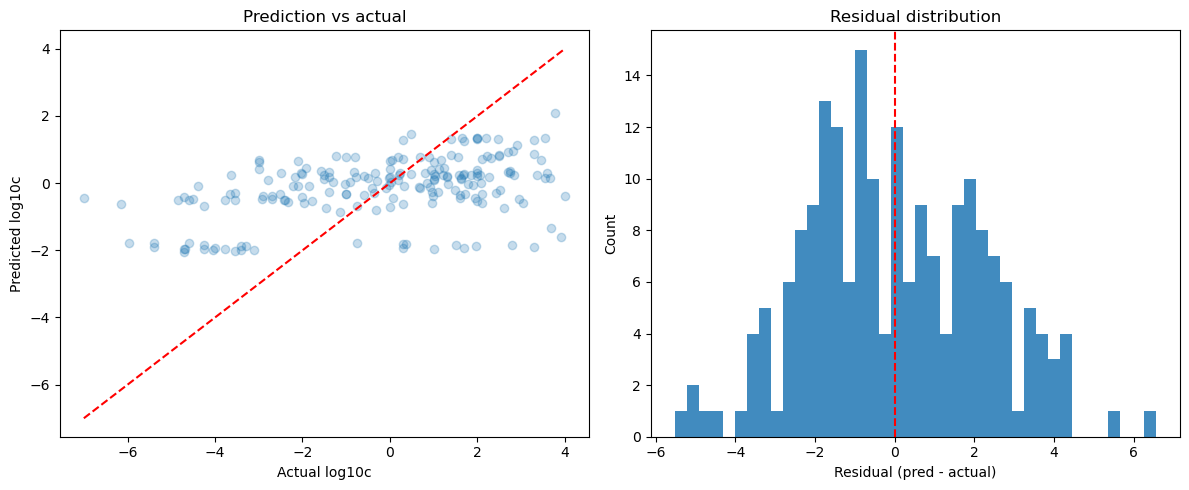

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["actual_log10c"], results_df["pred_log10c"], alpha=0.25)
plot_min = min(results_df["actual_log10c"].min(), results_df["pred_log10c"].min())
plot_max = max(results_df["actual_log10c"].max(), results_df["pred_log10c"].max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set_xlabel("Actual log10c")
axes[0].set_ylabel("Predicted log10c")
axes[0].set_title("Prediction vs actual")

axes[1].hist(results_df["residual_log10c"], bins=40, alpha=0.85)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred - actual)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


## Performance By Group

species_group


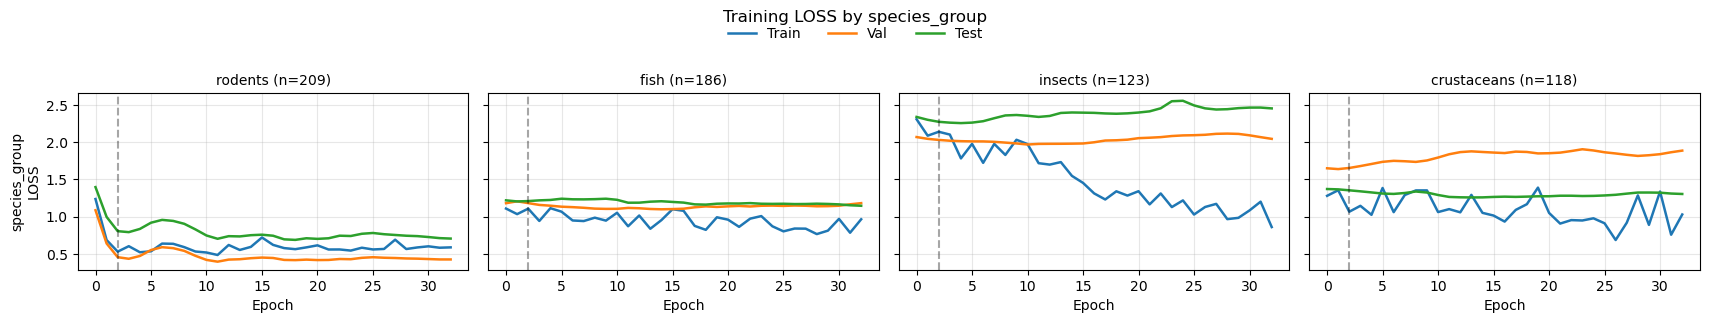

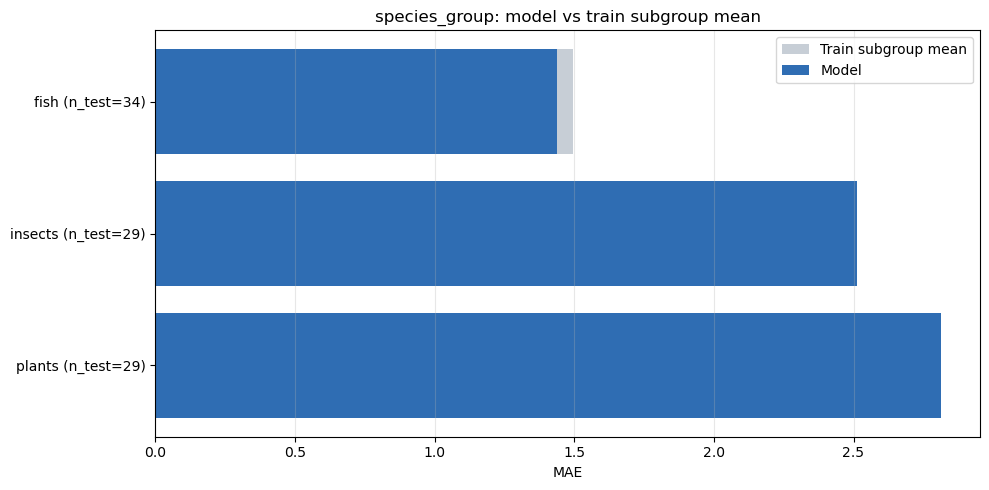

conc_unit


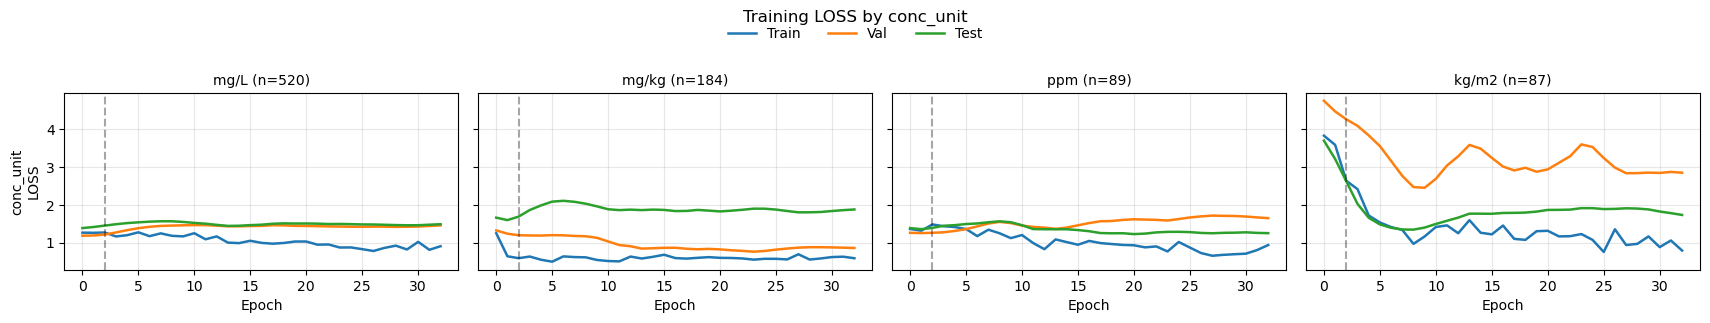

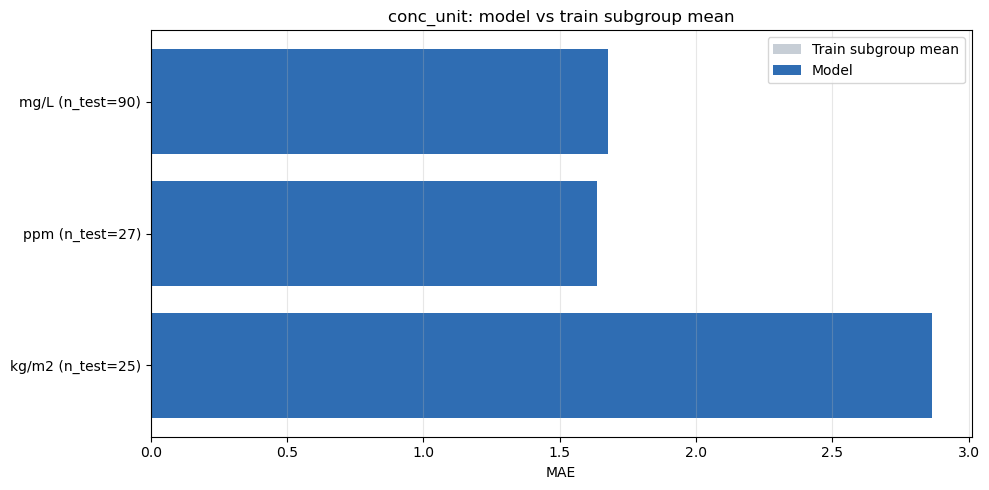

endpoint


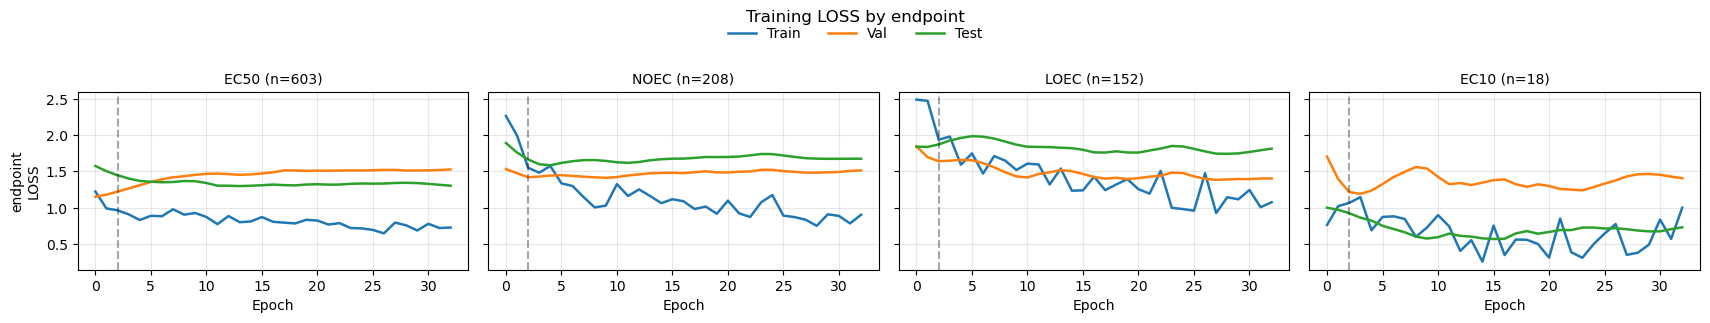

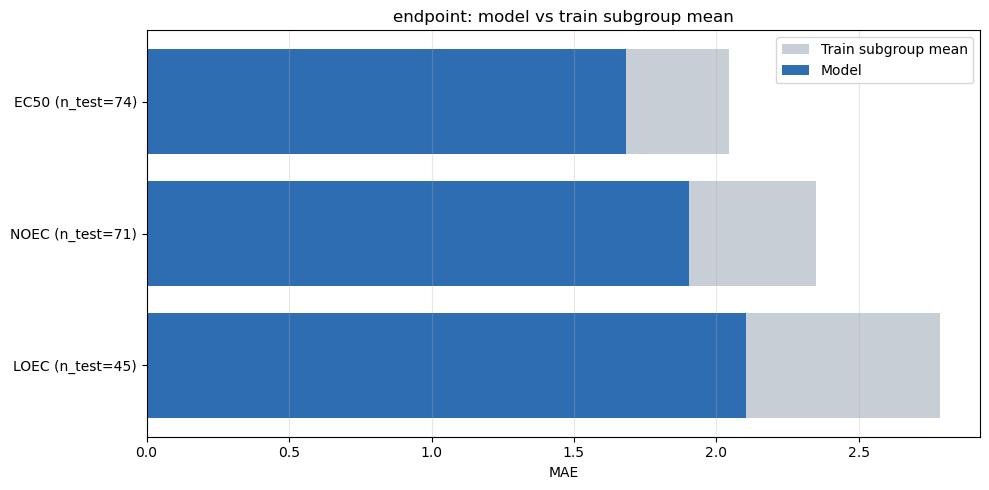

effect


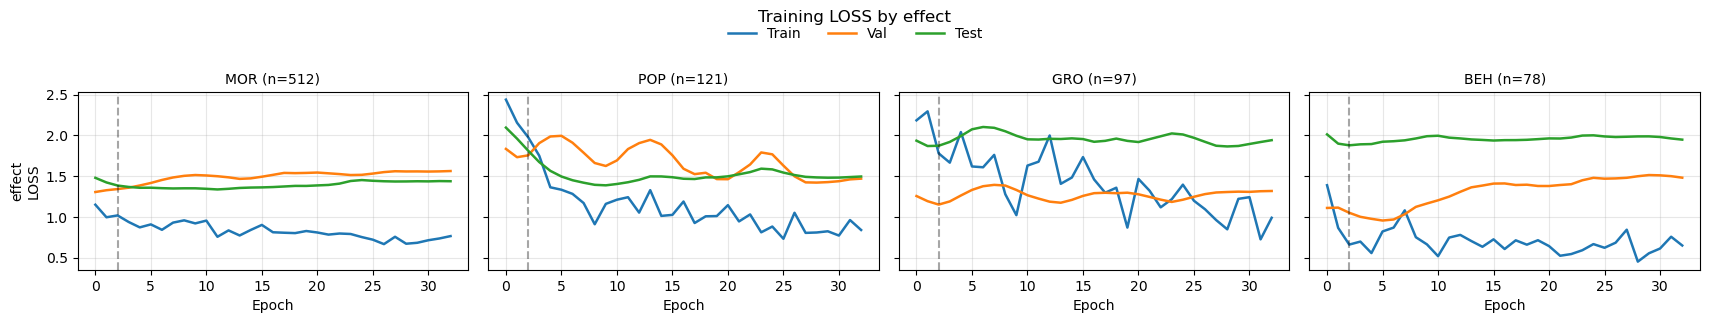

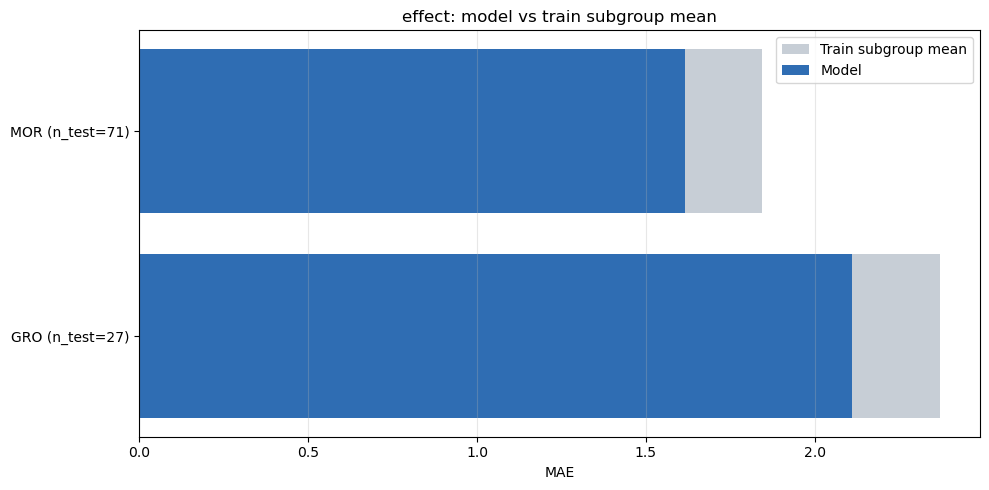

is_salt


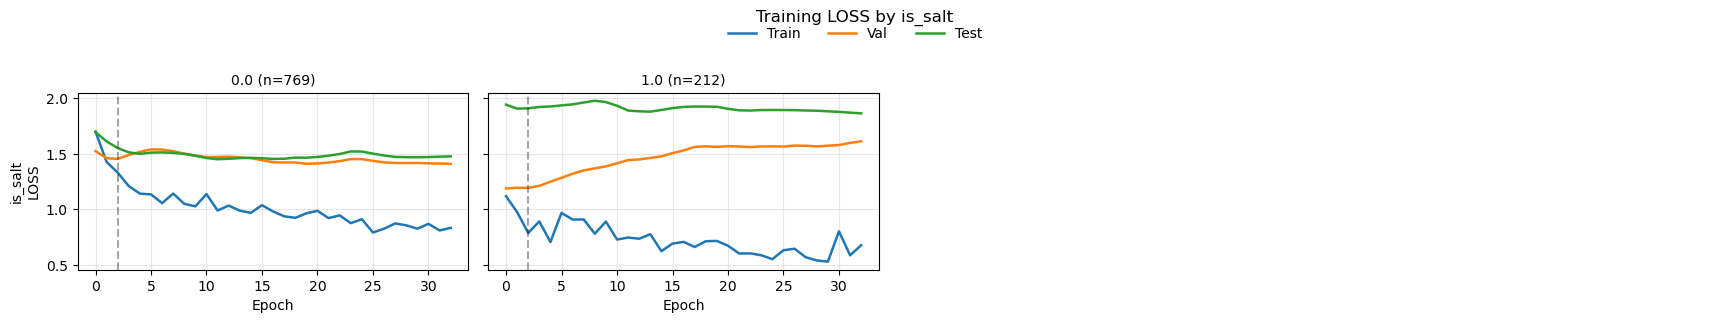

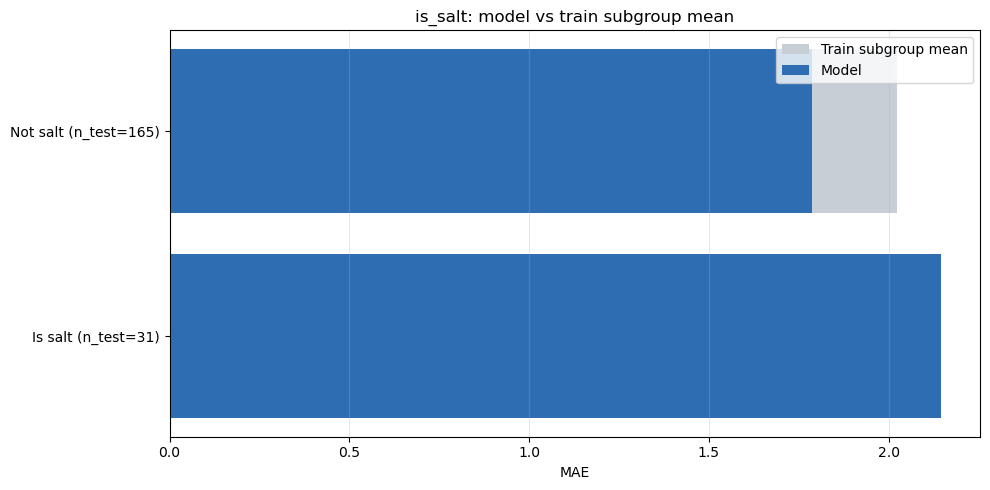

has_metal


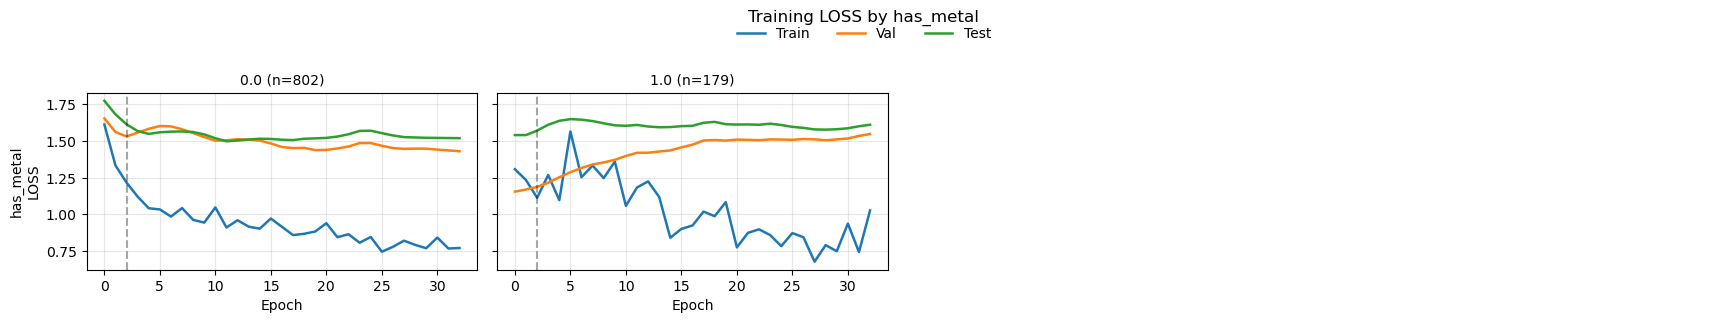

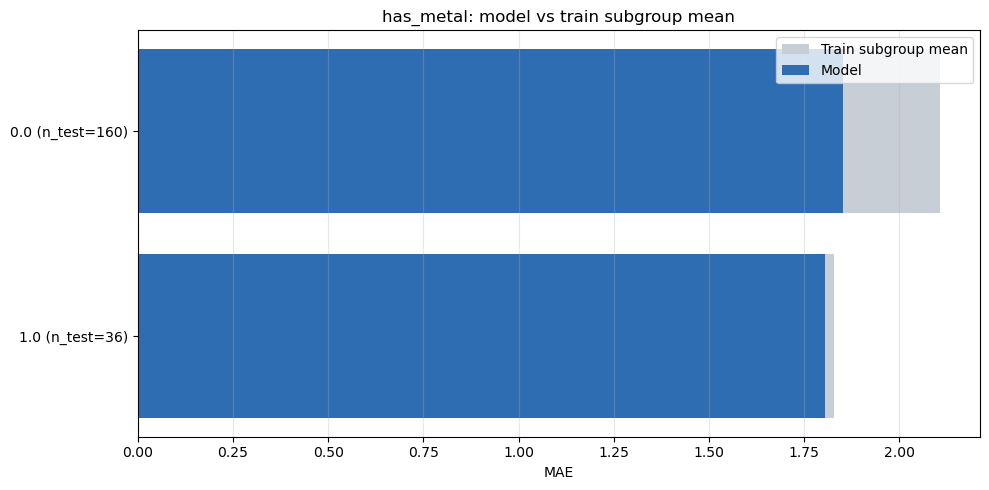

is_single_node


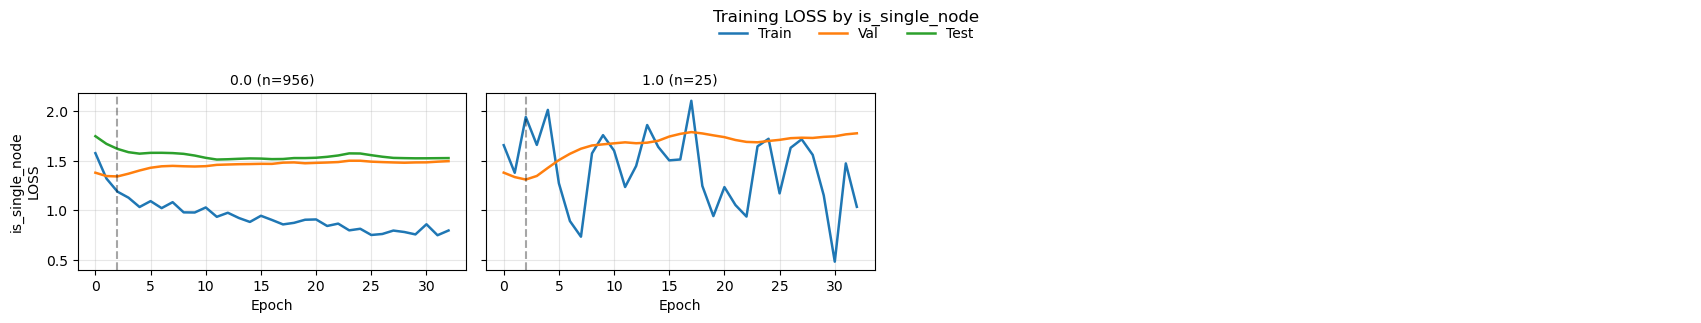

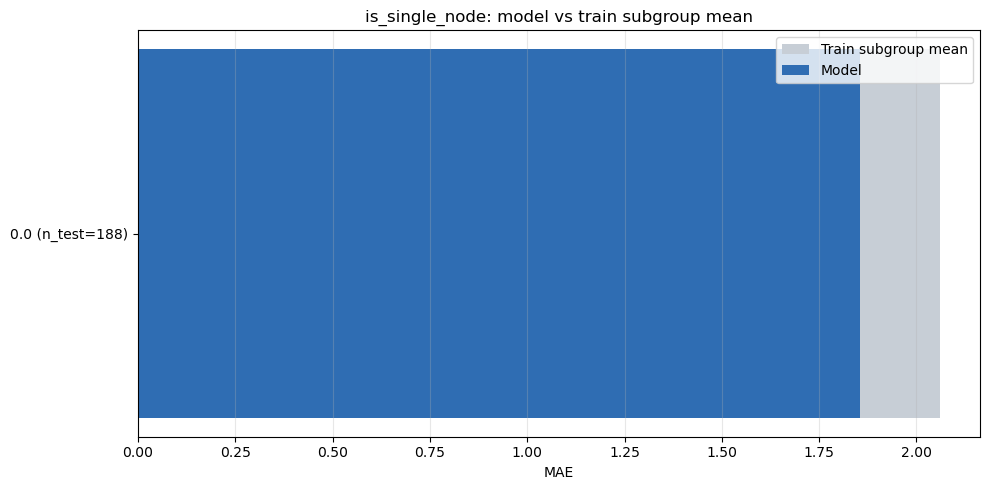

In [18]:
group_cols = [
    "conc_unit",
    "species_group",
    "endpoint",
    "effect",
    "fragment_bin",
    "has_metal_group",
]

# train_df["actual_log10c"] = [g.y.item() * target_std + target_mean for g in train_dataset]
train_df["actual_log10c"] = [g.y.item() for g in train_dataset]

group_summaries = {}

for category in categorical_cols:

    print(category)

    plot_group_training(
        history,
        record_categories=[category],
        metric="loss",   # or "mae" / "rmse"
        top_n=4,
        label_encoder=categorical_encoder,
    )
    
    summary = summarize_by_group(results_df, train_df, category, min_count=25)

    plot_group_mae(
        summary, 
        category=category,
    )
